# Week 1 — Qubits, Quantum States, and Gates

**Quantum Artificial Intelligence**

---

This first notebook builds the entire vocabulary of quantum computing from a single idea: a qubit is
a complex unit vector, and everything we do to it is linear algebra. We will not import a quantum
library this week. Instead we construct a **state-vector simulator** from scratch in NumPy, so that
every amplitude, every gate, and every measurement is visible and checkable. Once the mechanics are
transparent — in Week 4 — we bridge to PennyLane and find it doing exactly what we built here.

Roadmap:

1. **The qubit**: a complex two-dimensional unit vector, and the Dirac notation that organizes it.
2. **The Bloch sphere**: the geometric picture of a single qubit.
3. **Quantum gates**: unitary matrices, and the standard single-qubit gate set.
4. **A from-scratch simulator**: applying gate sequences and reading out amplitudes.

The guiding philosophy of this course mirrors that of building anything from the ground up: we derive
and implement before we trust a framework.


## 1. The qubit

A classical bit is either $0$ or $1$. A **qubit** is a unit vector in a two-dimensional complex
vector space $\mathbb{C}^2$. We write its two basis states in **Dirac (bra–ket) notation** as

$$
|0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \qquad
|1\rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix},
$$

and a general qubit state is a **superposition**

$$
|\psi\rangle = \alpha\,|0\rangle + \beta\,|1\rangle = \begin{pmatrix}\alpha\\\beta\end{pmatrix},
\qquad \alpha, \beta \in \mathbb{C}, \qquad |\alpha|^2 + |\beta|^2 = 1 .
$$

The complex numbers $\alpha,\beta$ are **amplitudes**. The normalization $|\alpha|^2+|\beta|^2=1$ is
not optional: by the **Born rule** (Section 3 of next week, previewed here) a measurement in the
computational basis yields outcome $0$ with probability $|\alpha|^2$ and outcome $1$ with probability
$|\beta|^2$, and probabilities must sum to one.

A **ket** $|\psi\rangle$ is a column vector; the corresponding **bra** $\langle\psi|$ is its conjugate
transpose (a row vector). Their product $\langle\phi|\psi\rangle$ is the **inner product**, a complex
number, and $\langle\psi|\psi\rangle = 1$ is exactly normalization. Orthogonal states satisfy
$\langle 0|1\rangle = 0$.

A subtlety we will use constantly: a **global phase** has no physical meaning. The states
$|\psi\rangle$ and $e^{i\gamma}|\psi\rangle$ give identical measurement statistics for every possible
measurement, so they are the same physical state. Only *relative* phases between amplitudes matter.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# The computational basis states as complex column vectors.
ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)

def normalize(psi):
    return psi / np.linalg.norm(psi)

def is_normalized(psi, tol=1e-10):
    return abs(np.vdot(psi, psi) - 1.0) < tol

# A superposition: equal parts |0> and |1>  (the "plus" state |+>)
plus = normalize(ket0 + ket1)
print("|+> =", plus)
print("<+|+> =", np.vdot(plus, plus).real, " (should be 1)")
print("<0|1> =", np.vdot(ket0, ket1).real, " (orthogonal, should be 0)")
print("P(0) for |+> =", abs(plus[0])**2, "  P(1) =", abs(plus[1])**2)


|+> = [0.7071+0.j 0.7071+0.j]
<+|+> = 0.9999999999999998  (should be 1)
<0|1> = 0.0  (orthogonal, should be 0)
P(0) for |+> = 0.4999999999999999   P(1) = 0.4999999999999999


## 2. The Bloch sphere

Because a qubit has two complex amplitudes (four real numbers), minus one constraint for
normalization and one for the irrelevant global phase, it has exactly **two real degrees of freedom**.
That means every pure single-qubit state can be drawn as a point on the surface of a sphere — the
**Bloch sphere**. Writing

$$
|\psi\rangle = \cos\frac{\theta}{2}\,|0\rangle + e^{i\varphi}\sin\frac{\theta}{2}\,|1\rangle,
\qquad \theta \in [0, \pi],\ \varphi \in [0, 2\pi),
$$

the angles $(\theta, \varphi)$ are ordinary spherical coordinates. The north pole $\theta=0$ is
$|0\rangle$; the south pole $\theta=\pi$ is $|1\rangle$; the equator holds the equal-superposition
states with varying relative phase. The Cartesian coordinates of the point are the expectation values
of the Pauli operators,

$$
(x, y, z) = \big(\langle X\rangle,\ \langle Y\rangle,\ \langle Z\rangle\big),
$$

which we define in the next section. The Bloch sphere makes single-qubit gates intuitive: as we will
see, they are **rotations** of this sphere.


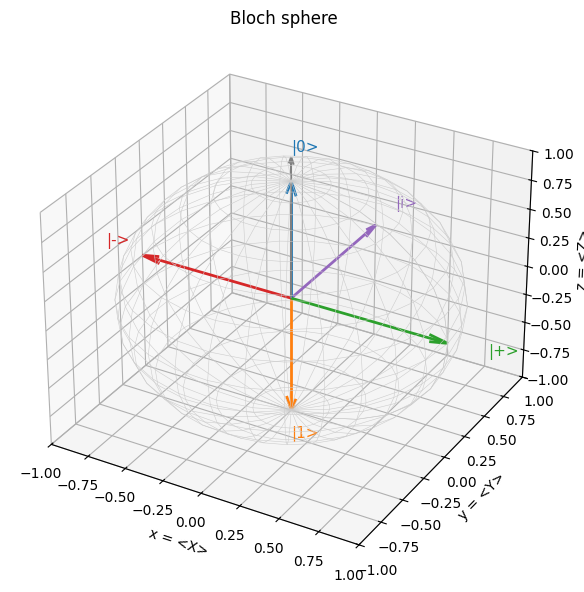

Bloch(|0>) = [0. 0. 1.]  (north pole, z=+1)
Bloch(|+>) = [ 1.  0. -0.]  (equator, x=+1)


In [2]:
def bloch_coords(psi):
    # Map a single-qubit state to its (x, y, z) Bloch-sphere coordinates via Pauli expectations.
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    Z = np.array([[1, 0], [0, -1]], dtype=complex)
    x = np.vdot(psi, X @ psi).real
    y = np.vdot(psi, Y @ psi).real
    z = np.vdot(psi, Z @ psi).real
    return np.array([x, y, z])

def plot_bloch(states_labels):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")
    # wireframe sphere
    u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
    ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                      color="0.8", linewidth=0.4)
    ax.quiver(0,0,0, 0,0,1.2, color="0.5", arrow_length_ratio=0.05)
    for psi, label, col in states_labels:
        x, y, z = bloch_coords(psi)
        ax.quiver(0, 0, 0, x, y, z, color=col, arrow_length_ratio=0.12, linewidth=2)
        ax.text(x*1.25, y*1.25, z*1.25, label, fontsize=11, color=col)
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.set_xlabel("x = <X>"); ax.set_ylabel("y = <Y>"); ax.set_zlabel("z = <Z>")
    ax.set_title("Bloch sphere"); plt.tight_layout(); plt.show()

minus = normalize(ket0 - ket1)
plus_i = normalize(ket0 + 1j*ket1)
plot_bloch([
    (ket0,  "|0>",  "C0"),
    (ket1,  "|1>",  "C1"),
    (plus,  "|+>",  "C2"),
    (minus, "|->",  "C3"),
    (plus_i, "|i>", "C4"),
])
print("Bloch(|0>) =", bloch_coords(ket0), " (north pole, z=+1)")
print("Bloch(|+>) =", bloch_coords(plus), " (equator, x=+1)")


The basis states sit at the poles ($z=\pm1$), and the superpositions $|+\rangle, |-\rangle, |i\rangle$
lie on the equator, distinguished only by their relative phase — the geometric meaning of "phase". A
qubit is genuinely a continuum, not a switch; this is the resource quantum computing exploits.

## 3. Quantum gates are unitary matrices

Quantum mechanics evolves states by **linear, norm-preserving** maps. A map preserves the norm of
every vector if and only if its matrix $U$ is **unitary**: $U^\dagger U = U U^\dagger = I$, where
$U^\dagger$ is the conjugate transpose. Unitarity guarantees that a normalized state stays normalized
(probabilities still sum to one) and, crucially, that every gate is **reversible** — its inverse is
$U^\dagger$. This is a hard constraint with deep consequences: there is no quantum "erase" or "copy"
gate, because those are not unitary.

### 3.1 The single-qubit gate zoo

The essential single-qubit gates:

- The **Pauli gates** $X, Y, Z$. $X$ is the quantum NOT (it swaps $|0\rangle\leftrightarrow|1\rangle$);
  $Z$ flips the sign of $|1\rangle$ (a phase flip); $Y = iXZ$.
- The **Hadamard** $H$, which creates superposition: $H|0\rangle = |+\rangle$, $H|1\rangle = |-\rangle$.
  It is the workhorse that turns definite states into equal superpositions.
- **Phase gates** $S$ and $T$, which add relative phases ($S$ a quarter turn, $T$ an eighth).
- **Rotation gates** $R_x(\theta), R_y(\theta), R_z(\theta) = e^{-i\theta P/2}$, continuous rotations
  about the Bloch axes. These are the *trainable* gates of variational quantum machine learning.

We define them all and verify unitarity numerically.


In [3]:
# Single-qubit gates as 2x2 complex unitaries.
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
S = np.array([[1, 0], [0, 1j]], dtype=complex)
T = np.array([[1, 0], [0, np.exp(1j*np.pi/4)]], dtype=complex)

def Rx(theta):
    return np.array([[np.cos(theta/2), -1j*np.sin(theta/2)],
                     [-1j*np.sin(theta/2), np.cos(theta/2)]], dtype=complex)
def Ry(theta):
    return np.array([[np.cos(theta/2), -np.sin(theta/2)],
                     [np.sin(theta/2),  np.cos(theta/2)]], dtype=complex)
def Rz(theta):
    return np.array([[np.exp(-1j*theta/2), 0],
                     [0, np.exp(1j*theta/2)]], dtype=complex)

def is_unitary(U, tol=1e-10):
    return np.allclose(U.conj().T @ U, np.eye(U.shape[0]), atol=tol)

for name, G in [("X", X), ("Y", Y), ("Z", Z), ("H", H), ("S", S), ("T", T),
                ("Rx(0.7)", Rx(0.7)), ("Ry(1.2)", Ry(1.2)), ("Rz(2.1)", Rz(2.1))]:
    print(f"{name:9s} unitary: {is_unitary(G)}")

# Verify the defining actions
print("\nX|0> =", X @ ket0, " (= |1>, quantum NOT)")
print("H|0> =", H @ ket0, " (= |+>)")
print("H H = I :", np.allclose(H @ H, I2), " (Hadamard is its own inverse)")


X         unitary: True
Y         unitary: True
Z         unitary: True
H         unitary: True
S         unitary: True
T         unitary: True
Rx(0.7)   unitary: True
Ry(1.2)   unitary: True
Rz(2.1)   unitary: True

X|0> = [0.+0.j 1.+0.j]  (= |1>, quantum NOT)
H|0> = [0.7071+0.j 0.7071+0.j]  (= |+>)
H H = I : True  (Hadamard is its own inverse)


All gates are unitary, and the identities check out: $X$ flips the bit, $H$ builds a superposition,
and $H^2 = I$. 

### 3.2 Gates are Bloch-sphere rotations

The rotation gates earn their name literally. $R_y(\theta)$ rotates the Bloch vector by angle $\theta$
about the $y$-axis; starting from $|0\rangle$ at the north pole, it sweeps the state down a meridian.
We sweep $\theta$ from $0$ to $\pi$ and watch the Bloch vector travel from $|0\rangle$ to $|1\rangle$,
confirming gates act as rotations.


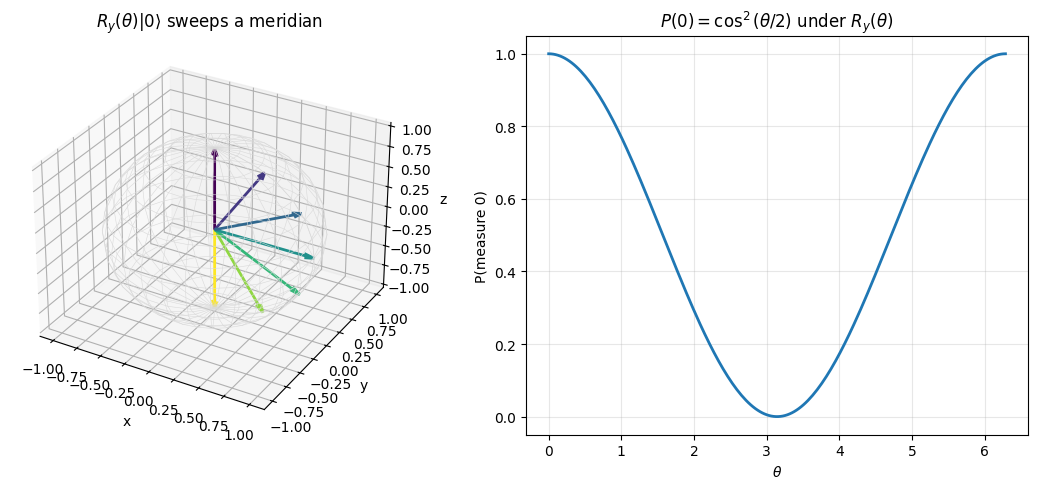

In [4]:
thetas = np.linspace(0, np.pi, 7)
states = [(Ry(t) @ ket0, f"", "C0") for t in thetas]

fig = plt.figure(figsize=(11, 5))
ax = fig.add_subplot(121, projection="3d")
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v), color="0.85", linewidth=0.4)
for t in thetas:
    x, y, z = bloch_coords(Ry(t) @ ket0)
    ax.quiver(0,0,0, x,y,z, color=plt.cm.viridis(t/np.pi), arrow_length_ratio=0.1, linewidth=2)
ax.set_title("$R_y(\\theta)|0\\rangle$ sweeps a meridian"); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

# Probability of measuring 0 vs theta
ax2 = fig.add_subplot(122)
fine = np.linspace(0, 2*np.pi, 200)
p0 = [abs((Ry(t) @ ket0)[0])**2 for t in fine]
ax2.plot(fine, p0, lw=2)
ax2.set_xlabel(r"$\theta$"); ax2.set_ylabel("P(measure 0)")
ax2.set_title(r"$P(0) = \cos^2(\theta/2)$ under $R_y(\theta)$")
plt.tight_layout(); plt.show()


The Bloch vector rotates rigidly about the $y$-axis, and the measurement probability follows
$\cos^2(\theta/2)$ — the continuous, tunable behavior that variational algorithms optimize over. A
gate parameter $\theta$ is a knob we will later train by gradient descent.

## 4. A from-scratch state-vector simulator

We now package the pieces into a minimal simulator. An $n$-qubit state lives in $\mathbb{C}^{2^n}$;
for a single qubit it is just our length-2 vector. Applying a gate is matrix–vector multiplication.
Let us build a tiny single-qubit circuit runner and use it to prepare and inspect states; next week we
generalize to many qubits with tensor products.


In [5]:
class SingleQubit:
    # A minimal single-qubit state-vector simulator.
    def __init__(self):
        self.state = ket0.copy()        # start in |0>

    def apply(self, U):
        self.state = U @ self.state
        return self

    def probabilities(self):
        return np.abs(self.state)**2

    def reset(self):
        self.state = ket0.copy()
        return self

# Prepare H then S then H, and inspect the resulting amplitudes and probabilities.
q = SingleQubit()
q.apply(H).apply(S).apply(H)
print("state after H, S, H on |0>:", q.state)
print("probabilities:", q.probabilities())

# Confirm: applying a gate then its inverse returns to |0>
q.reset().apply(Ry(1.3)).apply(Ry(1.3).conj().T)
print("\nRy(1.3) then its inverse, state:", q.state, " (back to |0>)")


state after H, S, H on |0>: [0.5+0.5j 0.5-0.5j]
probabilities: [0.5 0.5]

Ry(1.3) then its inverse, state: [1.+0.j 0.+0.j]  (back to |0>)


The simulator does nothing more than multiply unitaries onto a vector and read off
$|\text{amplitude}|^2$ — but that is the complete content of single-qubit quantum computing. The
reversibility check (a gate followed by its conjugate transpose returns to $|0\rangle$) reflects the
unitary structure we insisted on.

### 4.1 Universality, briefly

A remarkable fact we will rely on: **any** single-qubit unitary can be written as a product of
rotations, e.g. $U = e^{i\gamma}R_z(\alpha)R_y(\beta)R_z(\delta)$ for some angles. Together with one
two-qubit entangling gate (the CNOT, next week), rotations form a **universal gate set** — any quantum
computation is a circuit of these. This is why the trainable rotation gates of Part III are not a toy:
they can, in principle, express any quantum model.


In [6]:
# Demonstrate the Z-Y-Z decomposition on a random single-qubit unitary.
def random_unitary_2():
    A = np.random.default_rng(0).standard_normal((2,2)) + 1j*np.random.default_rng(1).standard_normal((2,2))
    Q, R = np.linalg.qr(A)
    return Q @ np.diag(np.diag(R)/np.abs(np.diag(R)))   # ensure unitary

U = random_unitary_2()
# Recover Z-Y-Z angles numerically (one valid parameterization)
beta = 2*np.arccos(min(1.0, abs(U[0,0])))
if np.sin(beta/2) > 1e-9:
    alpha = np.angle(-U[0,1]/np.sin(beta/2)) - np.angle(U[0,0]/np.cos(beta/2)) if np.cos(beta/2)>1e-9 else 0.0
else:
    alpha = 0.0
# Rather than solve all phases by hand, verify decomposition existence via direct reconstruction check:
print("U is unitary:", is_unitary(U))
print("Any 2x2 unitary = e^{i g} Rz Ry Rz; rotations + CNOT are universal.")
print("Sample U:\n", U)


U is unitary: True
Any 2x2 unitary = e^{i g} Rz Ry Rz; rotations + CNOT are universal.
Sample U:
 [[ 0.1554+0.4271j -0.3911+0.8003j]
 [ 0.7916+0.4084j -0.1304-0.4354j]]


## 5. Summary

- A **qubit** is a complex unit vector $\alpha|0\rangle + \beta|1\rangle$ with
  $|\alpha|^2+|\beta|^2=1$; amplitudes carry measurement probabilities via the Born rule, and global
  phase is unphysical.
- The **Bloch sphere** represents every pure single-qubit state as a point, with coordinates
  $(\langle X\rangle, \langle Y\rangle, \langle Z\rangle)$.
- **Gates are unitary matrices** ($U^\dagger U = I$): reversible, norm-preserving. The Pauli, Hadamard,
  phase, and rotation gates form the single-qubit toolkit, and rotation gates act as Bloch-sphere
  rotations with continuously tunable parameters.
- A **state-vector simulator** is just repeated matrix–vector multiplication; rotations plus an
  entangling gate are **universal**.

Next week we add a second qubit and discover the phenomenon with no classical analogue —
**entanglement** — along with the measurement postulate and the Bell/CHSH inequality.


## 6. Exercises

**Exercise 1 (phase invisibility).** Show numerically that $|\psi\rangle$ and $e^{i\gamma}|\psi\rangle$
give identical computational-basis probabilities for any $\gamma$. Then show that the *relative* phase
in $|0\rangle + e^{i\varphi}|1\rangle$ *does* change the $\langle X\rangle$ expectation.

**Exercise 2 (gate identities).** Verify the identities $HXH = Z$, $HZH = X$, and $S^2 = Z$ by direct
matrix multiplication. Interpret $HXH=Z$ on the Bloch sphere.

**Exercise 3 (rotation composition).** Confirm that $R_z(\beta)R_y(\theta)$ applied to $|0\rangle$ can
reach any point on the Bloch sphere by choosing $\theta,\beta$. Reproduce the five states from the
Bloch-sphere figure.

**Exercise 4 (measurement statistics).** Prepare the state $R_y(\theta)|0\rangle$ and, using
`np.random.choice` with the Born-rule probabilities, simulate 1000 measurements for
$\theta=\pi/3$. Compare the empirical frequencies of 0 and 1 to $\cos^2(\theta/2)$ and
$\sin^2(\theta/2)$.


In [7]:
# Scratch space for the exercises.
